In [ ]:
import pandas as pd
import os
from itertools import combinations
from collections import defaultdict

print(os.getcwd())

df = pd.read_csv('/content/leetcode_problems.csv')

edge_weights = defaultdict(int)

for _, row in df.iterrows():
    if pd.isna(row['tags']):
        continue
    tags = [t.strip() for t in str(row['tags']).split(',') if t.strip()]
    for t1, t2 in combinations(sorted(tags), 2):
        edge_weights[(t1, t2)] += 1

edges = pd.DataFrame(
    [(t1, t2, w) for (t1, t2), w in edge_weights.items()],
    columns=["Source", "Target", "Weight"]
)

tags = set()
for t1, t2 in edge_weights:
    tags.add(t1)
    tags.add(t2)

nodes = pd.DataFrame({
    "Id": list(tags),
    "Label": list(tags)
})

nodes_path = '/content/nodes.csv'
edges_path = '/content/edges.csv'

nodes.to_csv(nodes_path, index=False)
edges.to_csv(edges_path, index=False)

print("Saved:", nodes_path, edges_path)

# from google.colab import files
# files.download(nodes_path)
# files.download(edges_path)

/content
Saved: /content/nodes.csv /content/edges.csv


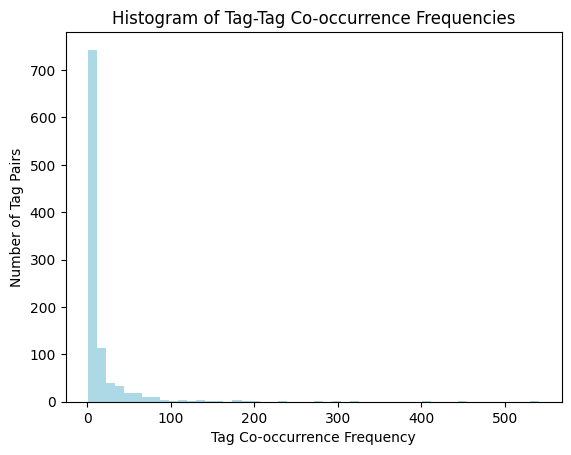

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

edges = pd.read_csv("edges.csv")

weights = edges["Weight"]

plt.hist(weights, bins=50, color= 'lightblue')
plt.xlabel("Tag Co-occurrence Frequency")
plt.ylabel("Number of Tag Pairs")
plt.title("Histogram of Tag-Tag Co-occurrence Frequencies")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("modularity.csv")

summary = df.groupby("Modularity_Class").size().reset_index(name="Num_Tags")

print(summary)

for c in sorted(df["Modularity_Class"].unique()):
    print("\nModularity_Class", c)
    subset = df[df["Modularity_Class"] == c]
    print(subset["Label"].value_counts().head(10))

   Modularity_Class  Num_Tags
0                 0         4
1                 1        36
2                 2        11
3                 3        15
4                 4         4

Modularity_Class 0
Label
Rolling Hash       1
Suffix Array       1
String Matching    1
Hash Function      1
Name: count, dtype: int64

Modularity_Class 1
Label
Queue                    1
Simulation               1
Backtracking             1
Binary Search            1
Segment Tree             1
Radix Sort               1
Dynamic Programming      1
Heap (Priority Queue)    1
Monotonic Queue          1
Interactive              1
Name: count, dtype: int64

Modularity_Class 2
Label
Recursion                     1
Brainteaser                   1
Number Theory                 1
Math                          1
Combinatorics                 1
Game Theory                   1
Geometry                      1
Reservoir Sampling            1
Randomized                    1
Probability and Statistics    1
Name: count, dty

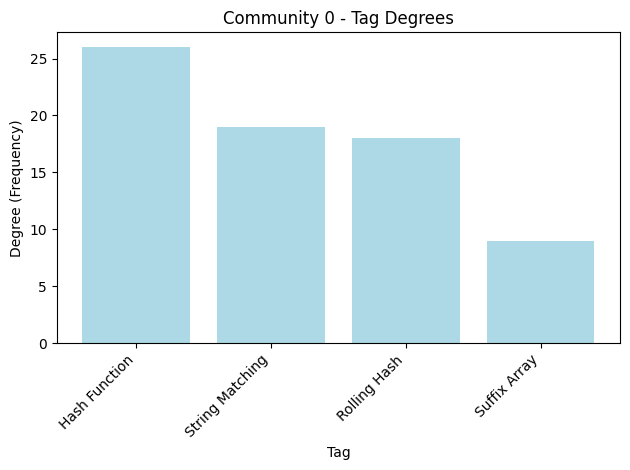

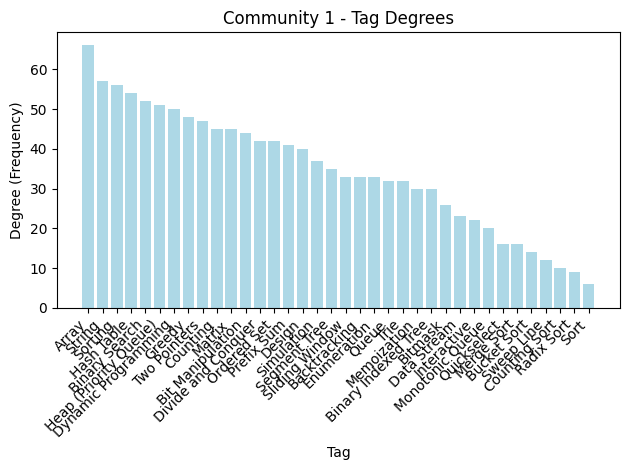

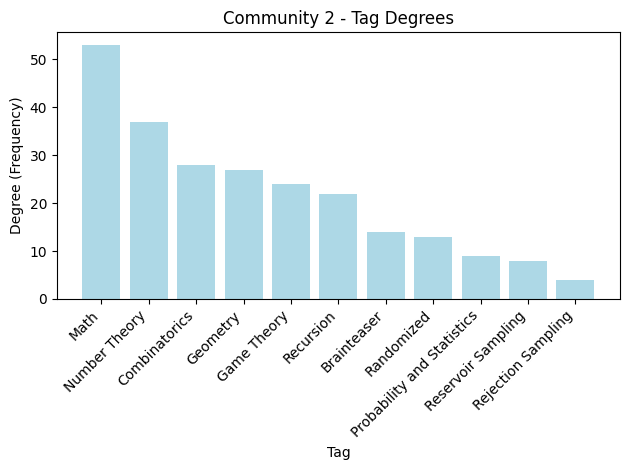

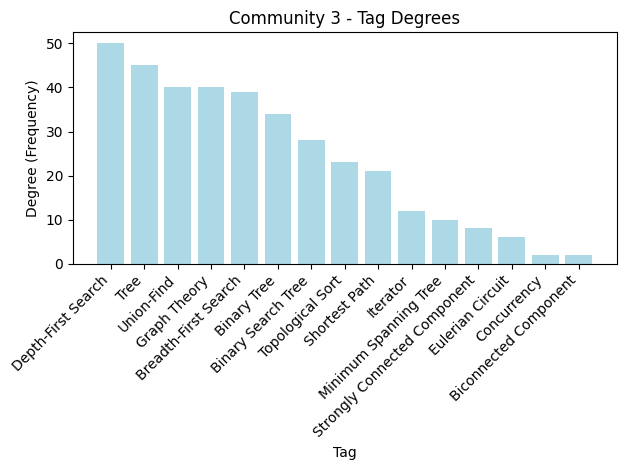

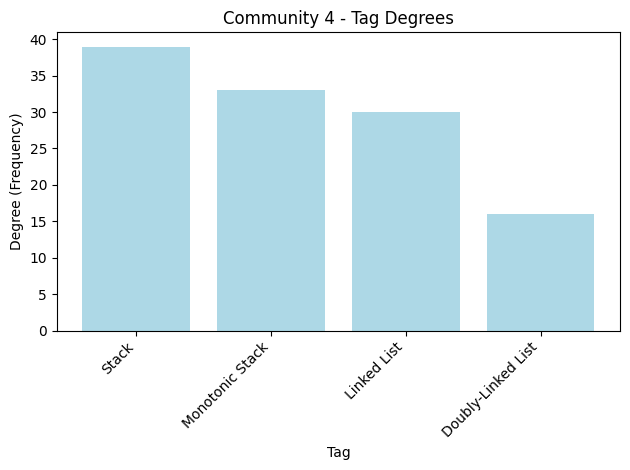

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("modularity.csv")

for c in sorted(df["Modularity_Class"].unique()):
    subset = df[df["Modularity_Class"] == c].sort_values(by="Frequency", ascending=False)

    plt.figure()
    plt.bar(subset["Label"], subset["Frequency"], color = 'lightblue')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel("Tag")
    plt.ylabel("Degree (Frequency)")
    plt.title(f"Community {c} - Tag Degrees")
    plt.tight_layout()
    plt.show()

difficulty
Easy      2.136898
Hard      3.552061
Medium    3.051496
Name: Degree, dtype: float64


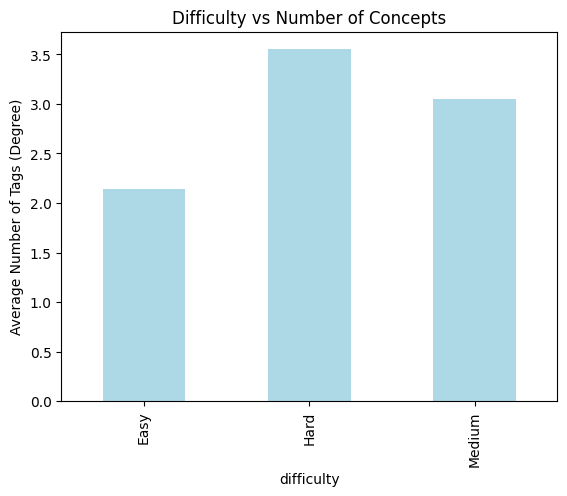

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("problem-tag.csv")

df = df[df["type"] == "Problem"]

group = df.groupby("difficulty")["Degree"].mean()

print(group)

group.plot(kind="bar", color = 'lightblue')
plt.ylabel("Average Number of Tags (Degree)")
plt.title("Difficulty vs Number of Concepts")
plt.show()